# Task 3 - SVM y Árboles de Decisión

## 1: Limpieza y Pre-procesamiento

In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración de visualización
plt.style.use('default')
sns.set_palette("husl")
%matplotlib inline

In [3]:
df = pd.read_csv('high_diamond_ranked_10min.csv')

print(f"Dimensiones del dataset: {df.shape}")
print(f"Filas: {df.shape[0]}, Columnas: {df.shape[1]}")
df.head()

Dimensiones del dataset: (9879, 40)
Filas: 9879, Columnas: 40


,gameId,blueWins,blueWardsPlaced,blueWardsDestroyed,blueFirstBlood,blueKills,blueDeaths,blueAssists,blueEliteMonsters,blueDragons,...,redTowersDestroyed,redTotalGold,redAvgLevel,redTotalExperience,redTotalMinionsKilled,redTotalJungleMinionsKilled,redGoldDiff,redExperienceDiff,redCSPerMin,redGoldPerMin
0,4519157822,0,28,2,1,9,6,11,0,0,...,0,16567,6.8,17047,197,55,-643,8,19.7,1656.7
1,4523371949,0,12,1,0,5,5,5,0,0,...,1,17620,6.8,17438,240,52,2908,1173,24.0,1762.0
2,4521474530,0,15,0,0,7,11,4,1,1,...,0,17285,6.8,17254,203,28,1172,1033,20.3,1728.5
3,4524384067,0,43,1,0,4,5,5,1,0,...,0,16478,7.0,17961,235,47,1321,7,23.5,1647.8
4,4436033771,0,75,4,0,6,6,6,0,0,...,0,17404,7.0,18313,225,67,1004,-230,22.5,1740.4


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9879 entries, 0 to 9878
Data columns (total 40 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   gameId                        9879 non-null   int64  
 1   blueWins                      9879 non-null   int64  
 2   blueWardsPlaced               9879 non-null   int64  
 3   blueWardsDestroyed            9879 non-null   int64  
 4   blueFirstBlood                9879 non-null   int64  
 5   blueKills                     9879 non-null   int64  
 6   blueDeaths                    9879 non-null   int64  
 7   blueAssists                   9879 non-null   int64  
 8   blueEliteMonsters             9879 non-null   int64  
 9   blueDragons                   9879 non-null   int64  
 10  blueHeralds                   9879 non-null   int64  
 11  blueTowersDestroyed           9879 non-null   int64  
 12  blueTotalGold                 9879 non-null   int64  
 13  blu

In [8]:
df.describe()

,gameId,blueWins,blueWardsPlaced,blueWardsDestroyed,blueFirstBlood,blueKills,blueDeaths,blueAssists,blueEliteMonsters,blueDragons,...,redTowersDestroyed,redTotalGold,redAvgLevel,redTotalExperience,redTotalMinionsKilled,redTotalJungleMinionsKilled,redGoldDiff,redExperienceDiff,redCSPerMin,redGoldPerMin
count,9.879000e+03,9879.000000,9879.000000,9879.000000,9879.000000,9879.000000,9879.000000,9879.000000,9879.000000,9879.000000,...,9879.000000,9879.000000,9879.000000,9879.000000,9879.000000,9879.000000,9879.000000,9879.000000,9879.000000,9879.000000
mean,4.500084e+09,0.499038,22.288288,2.824881,0.504808,6.183925,6.137666,6.645106,0.549954,0.361980,...,0.043021,16489.041401,6.925316,17961.730438,217.349226,51.313088,-14.414111,33.620306,21.734923,1648.904140
std,2.757328e+07,0.500024,18.019177,2.174998,0.500002,3.011028,2.933818,4.064520,0.625527,0.480597,...,0.216900,1490.888406,0.305311,1198.583912,21.911668,10.027885,2453.349179,1920.370438,2.191167,149.088841
min,4.295358e+09,0.000000,5.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,11212.000000,4.800000,10465.000000,107.000000,4.000000,-11467.000000,-8348.000000,10.700000,1121.200000
25%,4.483301e+09,0.000000,14.000000,1.000000,0.000000,4.000000,4.000000,4.000000,0.000000,0.000000,...,0.000000,15427.500000,6.800000,17209.500000,203.000000,44.000000,-1596.000000,-1212.000000,20.300000,1542.750000
50%,4.510920e+09,0.000000,16.000000,3.000000,1.000000,6.000000,6.000000,6.000000,0.000000,0.000000,...,0.000000,16378.000000,7.000000,17974.000000,218.000000,51.000000,-14.000000,28.000000,21.800000,1637.800000
75%,4.521733e+09,1.000000,20.000000,4.000000,1.000000,8.000000,8.000000,9.000000,1.000000,1.000000,...,0.000000,17418.500000,7.200000,18764.500000,233.000000,57.000000,1585.500000,1290.500000,23.300000,1741.850000
max,4.527991e+09,1.000000,250.000000,27.000000,1.000000,22.000000,22.000000,29.000000,2.000000,1.000000,...,2.000000,22732.000000,8.200000,22269.000000,289.000000,92.000000,10830.000000,9333.000000,28.900000,2273.200000


### 1.a. Eliminación de Redundancia y Data Leakage

In [5]:
# Lista de columnas a eliminar
columns_to_drop = ['gameId']  # Identificador sin valor predictivo

# Eliminar todas las columnas que empiezan con 'red' (redundantes y data leakage)
red_columns = [col for col in df.columns if col.startswith('red')]
columns_to_drop.extend(red_columns)

print(f"Columnas a eliminar ({len(columns_to_drop)}):")
for col in columns_to_drop:
    print(f"  - {col}")

Columnas a eliminar (20):
  - gameId
  - redWardsPlaced
  - redWardsDestroyed
  - redFirstBlood
  - redKills
  - redDeaths
  - redAssists
  - redEliteMonsters
  - redDragons
  - redHeralds
  - redTowersDestroyed
  - redTotalGold
  - redAvgLevel
  - redTotalExperience
  - redTotalMinionsKilled
  - redTotalJungleMinionsKilled
  - redGoldDiff
  - redExperienceDiff
  - redCSPerMin
  - redGoldPerMin


In [6]:
# Eliminar las columnas
df_clean = df.drop(columns=columns_to_drop)

print(f"\nDimensiones después de limpieza: {df_clean.shape}")
print(f"\nColumnas restantes ({df_clean.shape[1]}):")
for i, col in enumerate(df_clean.columns, 1):
    print(f"  {i}. {col}")


Dimensiones después de limpieza: (9879, 20)

Columnas restantes (20):
  1. blueWins
  2. blueWardsPlaced
  3. blueWardsDestroyed
  4. blueFirstBlood
  5. blueKills
  6. blueDeaths
  7. blueAssists
  8. blueEliteMonsters
  9. blueDragons
  10. blueHeralds
  11. blueTowersDestroyed
  12. blueTotalGold
  13. blueAvgLevel
  14. blueTotalExperience
  15. blueTotalMinionsKilled
  16. blueTotalJungleMinionsKilled
  17. blueGoldDiff
  18. blueExperienceDiff
  19. blueCSPerMin
  20. blueGoldPerMin


In [7]:
# Verificar valores nulos
print("Valores nulos por columna:")
print(df_clean.isnull().sum())

Valores nulos por columna:
blueWins                        0
blueWardsPlaced                 0
blueWardsDestroyed              0
blueFirstBlood                  0
blueKills                       0
blueDeaths                      0
blueAssists                     0
blueEliteMonsters               0
blueDragons                     0
blueHeralds                     0
blueTowersDestroyed             0
blueTotalGold                   0
blueAvgLevel                    0
blueTotalExperience             0
blueTotalMinionsKilled          0
blueTotalJungleMinionsKilled    0
blueGoldDiff                    0
blueExperienceDiff              0
blueCSPerMin                    0
blueGoldPerMin                  0
dtype: int64


In [8]:
# Verificar distribución de la variable objetivo
print("Distribución de la variable objetivo (blueWins):")
print(df_clean['blueWins'].value_counts())
print(f"\nPorcentaje de victorias del equipo azul: {df_clean['blueWins'].mean()*100:.2f}%")

Distribución de la variable objetivo (blueWins):
blueWins
0    4949
1    4930
Name: count, dtype: int64

Porcentaje de victorias del equipo azul: 49.90%


### 1.b Escalado

In [9]:
# Separar variable objetivo (y) de las features (X)
X = df_clean.drop('blueWins', axis=1)
y = df_clean['blueWins']

print(f"Shape de X (features): {X.shape}")
print(f"Shape de y (target): {y.shape}")

print("\nFeatures incluidas en X:")
for i, col in enumerate(X.columns, 1):
    print(f"  {i}. {col}")

Shape de X (features): (9879, 19)
Shape de y (target): (9879,)

Features incluidas en X:
  1. blueWardsPlaced
  2. blueWardsDestroyed
  3. blueFirstBlood
  4. blueKills
  5. blueDeaths
  6. blueAssists
  7. blueEliteMonsters
  8. blueDragons
  9. blueHeralds
  10. blueTowersDestroyed
  11. blueTotalGold
  12. blueAvgLevel
  13. blueTotalExperience
  14. blueTotalMinionsKilled
  15. blueTotalJungleMinionsKilled
  16. blueGoldDiff
  17. blueExperienceDiff
  18. blueCSPerMin
  19. blueGoldPerMin


In [10]:
# Dividir en train y test con 80/20
# random_state=42 para reproducibilidad
# stratify=y para mantener la misma proporción de clases en train y test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y
)

print(f"Train set:")
print(f"  X_train: {X_train.shape}")
print(f"  y_train: {y_train.shape}")
print(f"  Distribución: {y_train.value_counts().to_dict()}")

print(f"\nTest set:")
print(f"  X_test: {X_test.shape}")
print(f"  y_test: {y_test.shape}")
print(f"  Distribución: {y_test.value_counts().to_dict()}")

Train set:
  X_train: (7903, 19)
  y_train: (7903,)
  Distribución: {0: 3959, 1: 3944}

Test set:
  X_test: (1976, 19)
  y_test: (1976,)
  Distribución: {0: 990, 1: 986}


#### Explicacion del escalado con svm y arboles

##### SVM (Support Vector Machines):

SVM necesita escalado porque su objetivo es encontrar el hiperplano que maximiza el margen entre clases. 

Problema sin escalado:
- Si una feature tiene rango [15,000-18,000] (ej: `blueTotalGold`) y otra tiene rango [0-15] (ej: `blueKills`), la feature con mayor magnitud dominara el cálculo del margen, haciendo que las demás features sean prácticamente ignoradas.
- El algoritmo de optimización (gradiente) converge mas lento o puede no converger.
- Los kernels (especialmente RBF) son sensibles a la escala. El parámetro gamma en RBF controla el radio de influencia. Si las features no están escaladas, el modelo puede tener un comportamiento impredecible.

StandardScaler transforma cada feature para que tenga:
- Media = 0
- Desviación estándar = 1
- Fórmula: `z = (x - μ) / σ`

##### Árboles de Decisión:

Los árboles no necesitan escalado porque son modelos basados en reglas y divisiones.

- Un árbol hace preguntas del tipo: *"¿`blueTotalGold` > 16,500?"* o *"¿`blueKills` > 5?"*
- Estas divisiones son ivariantes a la escala.  No importa si `blueTotalGold` está en [15000, 18000] o en [-1, 1] después de escalar, la división sigue siendo la misma en términos relativos.
- La función de costo (Gini impurity) solo depende de la puerza de las divisiones, no de las distancias entre puntos.
- No hay cálculo de distancias, gradientes, ni optimización numérica que se vea afectada por la escala.

In [11]:
# Crear el scaler
scaler = StandardScaler()

# Entrenar el scaler con los datos de entrenamiento
scaler.fit(X_train)

# Aplicar la transformación a train y test
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convertir de nuevo a DataFrame para mantener los nombres de columnas
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

print("Escalado completado!")
print(f"\nX_train_scaled shape: {X_train_scaled.shape}")
print(f"X_test_scaled shape: {X_test_scaled.shape}")

Escalado completado!

X_train_scaled shape: (7903, 19)
X_test_scaled shape: (1976, 19)


In [12]:
#comparacion antes y despues del escalado
print("ANTES del escalado (X_train - primeras 3 filas):")
print(X_train.head(3))

print("\nDESPUÉS del escalado (X_train_scaled - primeras 3 filas):")
print(X_train_scaled.head(3))

ANTES del escalado (X_train - primeras 3 filas):
      blueWardsPlaced  blueWardsDestroyed  blueFirstBlood  blueKills  \
2393               11                   3               0          7   
4211               91                   3               1          6   
7684               20                   6               1         11   

      blueDeaths  blueAssists  blueEliteMonsters  blueDragons  blueHeralds  \
2393           3            7                  0            0            0   
4211           1            4                  2            1            1   
7684           8           12                  1            1            0   

      blueTowersDestroyed  blueTotalGold  blueAvgLevel  blueTotalExperience  \
2393                    0          16464           7.2                18030   
4211                    0          17016           7.2                19237   
7684                    0          19349           7.2                19673   

      blueTotalMinionsKilled  bl

In [13]:
print("Estadísticas ANTES del escalado:")
print(X_train.describe().loc[['mean', 'std']])

print("\nEstadísticas DESPUÉS del escalado (media ≈ 0, std ≈ 1):")
print(X_train_scaled.describe().loc[['mean', 'std']])

Estadísticas ANTES del escalado:
      blueWardsPlaced  blueWardsDestroyed  blueFirstBlood  blueKills  \
mean        22.390105            2.849424        0.504745   6.177907   
std         18.172416            2.181258        0.500009   3.006991   

      blueDeaths  blueAssists  blueEliteMonsters  blueDragons  blueHeralds  \
mean    6.139947     6.636847           0.549665     0.362394     0.187271   
std     2.913440     4.063152           0.624953     0.480722     0.390153   

      blueTowersDestroyed  blueTotalGold  blueAvgLevel  blueTotalExperience  \
mean             0.051626   16500.307099      6.916462         17927.073896   
std              0.247727    1530.688273      0.301386          1191.996588   

      blueTotalMinionsKilled  blueTotalJungleMinionsKilled  blueGoldDiff  \
mean              216.689105                     50.461723      7.674934   
std                21.776130                      9.909079   2430.920911   

      blueExperienceDiff  blueCSPerMin  blueGold

## 2: Support Vector Machines (SVM)

In [15]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import time

### 2.a .Entrene un modelo SVM con Kernel Lineal. 

In [16]:
# Crear el modelo SVM con kernel lineal
# C=1.0 es el parámetro de regularización (trade-off entre margen y errores)
svm_linear = SVC(kernel='linear', C=1.0, random_state=42)

# Entrenar el modelo (usamos X_train_scaled porque SVM necesita escalado)
start_time = time.time()
svm_linear.fit(X_train_scaled, y_train)
training_time_linear = time.time() - start_time

print(f"Tiempo de entrenamiento: {training_time_linear:.4f} segundos")
print(f"Número de support vectors: {svm_linear.n_support_}")
print(f"  - Clase 0 (Red Wins): {svm_linear.n_support_[0]} support vectors")
print(f"  - Clase 1 (Blue Wins): {svm_linear.n_support_[1]} support vectors")
print(f"Total de support vectors: {sum(svm_linear.n_support_)}")

# Hacer predicciones en el conjunto de prueba
y_pred_linear = svm_linear.predict(X_test_scaled)

# Calcular accuracy
accuracy_linear = accuracy_score(y_test, y_pred_linear)
print(f"\nAccuracy en Test Set: {accuracy_linear:.4f} ({accuracy_linear*100:.2f}%)")

# Matriz de confusión
cm_linear = confusion_matrix(y_test, y_pred_linear)
print("\nMatriz de Confusión:")
print(cm_linear)

# Reporte de clasificación
print("\nReporte de Clasificación:")
print(classification_report(y_test, y_pred_linear, target_names=['Red Wins (0)', 'Blue Wins (1)']))

Tiempo de entrenamiento: 2.3904 segundos
Número de support vectors: [2429 2430]
  - Clase 0 (Red Wins): 2429 support vectors
  - Clase 1 (Blue Wins): 2430 support vectors
Total de support vectors: 4859

Accuracy en Test Set: 0.7196 (71.96%)

Matriz de Confusión:
[[710 280]
 [274 712]]

Reporte de Clasificación:
               precision    recall  f1-score   support

 Red Wins (0)       0.72      0.72      0.72       990
Blue Wins (1)       0.72      0.72      0.72       986

     accuracy                           0.72      1976
    macro avg       0.72      0.72      0.72      1976
 weighted avg       0.72      0.72      0.72      1976



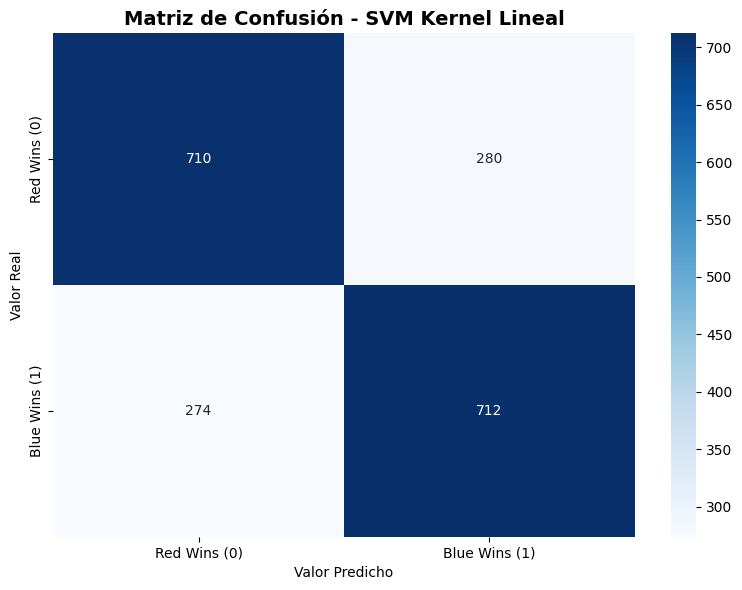

In [17]:
# Visualizar la matriz de confusión
plt.figure(figsize=(8, 6))
sns.heatmap(cm_linear, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Red Wins (0)', 'Blue Wins (1)'],
            yticklabels=['Red Wins (0)', 'Blue Wins (1)'])
plt.title('Matriz de Confusión - SVM Kernel Lineal', fontsize=14, fontweight='bold')
plt.ylabel('Valor Real')
plt.xlabel('Valor Predicho')
plt.tight_layout()
plt.show()

### 2.b. SVM con Kernel RBF (Radial Basis Function)


In [18]:
# Crear el modelo SVM con kernel RBF
# gamma='scale': gamma = 1 / (n_features * X.var())
svm_rbf = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)

# Entrenar el modelo
start_time = time.time()
svm_rbf.fit(X_train_scaled, y_train)
training_time_rbf = time.time() - start_time

print(f"Tiempo de entrenamiento: {training_time_rbf:.4f} segundos")
print(f"Número de support vectors: {svm_rbf.n_support_}")
print(f"  - Clase 0 (Red Wins): {svm_rbf.n_support_[0]} support vectors")
print(f"  - Clase 1 (Blue Wins): {svm_rbf.n_support_[1]} support vectors")
print(f"Total de support vectors: {sum(svm_rbf.n_support_)}")

# Hacer predicciones
y_pred_rbf = svm_rbf.predict(X_test_scaled)

# Calcular accuracy
accuracy_rbf = accuracy_score(y_test, y_pred_rbf)
print(f"\nAccuracy en Test Set: {accuracy_rbf:.4f} ({accuracy_rbf*100:.2f}%)")

# Matriz de confusión
cm_rbf = confusion_matrix(y_test, y_pred_rbf)
print("\nMatriz de Confusión:")
print(cm_rbf)

# Reporte de clasificación
print("\nReporte de Clasificación:")
print(classification_report(y_test, y_pred_rbf, target_names=['Red Wins (0)', 'Blue Wins (1)']))

Tiempo de entrenamiento: 1.6860 segundos
Número de support vectors: [2441 2496]
  - Clase 0 (Red Wins): 2441 support vectors
  - Clase 1 (Blue Wins): 2496 support vectors
Total de support vectors: 4937

Accuracy en Test Set: 0.7186 (71.86%)

Matriz de Confusión:
[[721 269]
 [287 699]]

Reporte de Clasificación:
               precision    recall  f1-score   support

 Red Wins (0)       0.72      0.73      0.72       990
Blue Wins (1)       0.72      0.71      0.72       986

     accuracy                           0.72      1976
    macro avg       0.72      0.72      0.72      1976
 weighted avg       0.72      0.72      0.72      1976



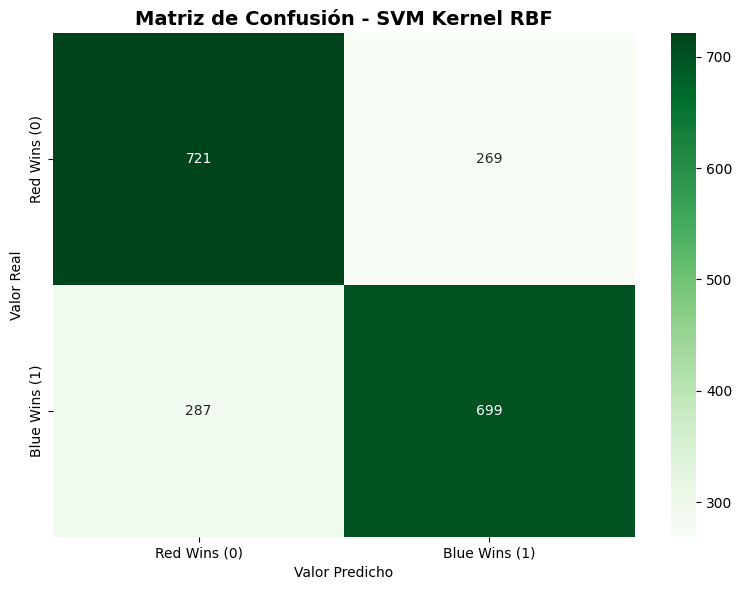

In [19]:
# Visualizar la matriz de confusión
plt.figure(figsize=(8, 6))
sns.heatmap(cm_rbf, annot=True, fmt='d', cmap='Greens', 
            xticklabels=['Red Wins (0)', 'Blue Wins (1)'],
            yticklabels=['Red Wins (0)', 'Blue Wins (1)'])
plt.title('Matriz de Confusión - SVM Kernel RBF', fontsize=14, fontweight='bold')
plt.ylabel('Valor Real')
plt.xlabel('Valor Predicho')
plt.tight_layout()
plt.show()

### 2.c. Comparación de Accuracy

In [20]:
# Crear DataFrame comparativo
comparison_df = pd.DataFrame({
    'Métrica': ['Accuracy', 'Tiempo de Entrenamiento (s)', 'Total Support Vectors'],
    'SVM Lineal': [
        f'{accuracy_linear:.4f} ({accuracy_linear*100:.2f}%)',
        f'{training_time_linear:.4f}',
        sum(svm_linear.n_support_)
    ],
    'SVM RBF': [
        f'{accuracy_rbf:.4f} ({accuracy_rbf*100:.2f}%)',
        f'{training_time_rbf:.4f}',
        sum(svm_rbf.n_support_)
    ]
})

print(comparison_df.to_string(index=False))

# Determinar cuál modelo es mejor
if accuracy_rbf > accuracy_linear:
    diff = (accuracy_rbf - accuracy_linear) * 100
    print(f"El kernel RBF tuvo MEJOR desempeño (+{diff:.2f}% accuracy)")
elif accuracy_rbf < accuracy_linear:
    diff = (accuracy_linear - accuracy_rbf) * 100
    print(f"El kernel Lineal tuvo MEJOR desempeño (+{diff:.2f}% accuracy)")
else:
    print("Ambos kernels tuvieron el MISMO desempeño")

                    Métrica      SVM Lineal         SVM RBF
                   Accuracy 0.7196 (71.96%) 0.7186 (71.86%)
Tiempo de Entrenamiento (s)          2.3904          1.6860
      Total Support Vectors            4859            4937
El kernel Lineal tuvo MEJOR desempeño (+0.10% accuracy)


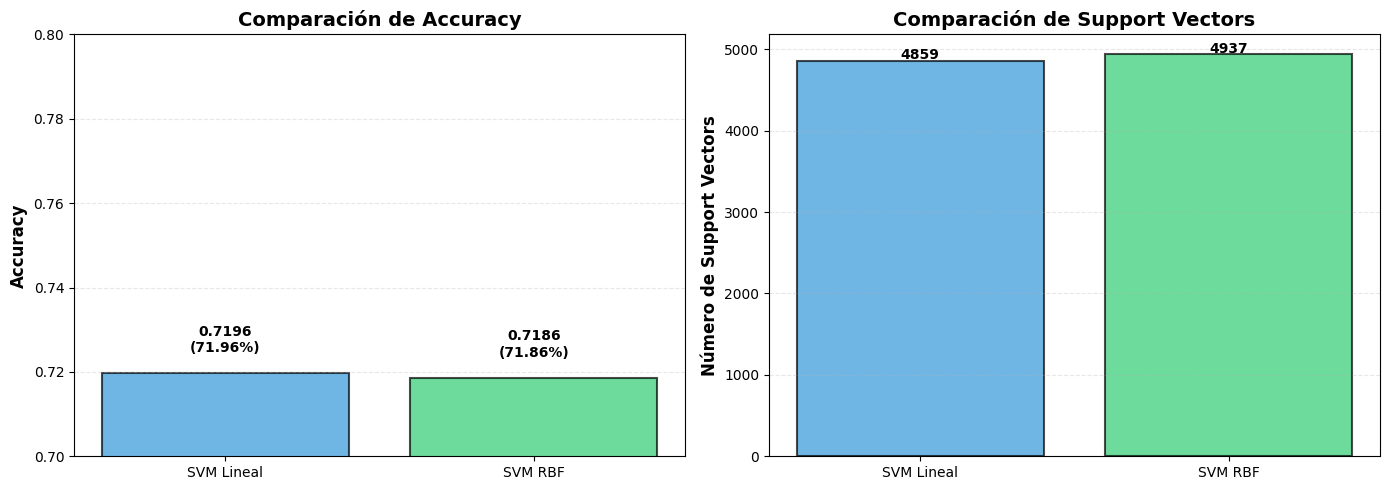

In [21]:
# Gráfico de barras comparativo
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: Accuracy
models = ['SVM Lineal', 'SVM RBF']
accuracies = [accuracy_linear, accuracy_rbf]
colors = ['#3498db', '#2ecc71']

ax[0].bar(models, accuracies, color=colors, alpha=0.7, edgecolor='black', linewidth=1.5)
ax[0].set_ylabel('Accuracy', fontsize=12, fontweight='bold')
ax[0].set_title('Comparación de Accuracy', fontsize=14, fontweight='bold')
ax[0].set_ylim([0.7, 0.8])
ax[0].grid(axis='y', alpha=0.3, linestyle='--')

# Agregar valores encima de las barras
for i, (model, acc) in enumerate(zip(models, accuracies)):
    ax[0].text(i, acc + 0.005, f'{acc:.4f}\n({acc*100:.2f}%)', 
               ha='center', fontsize=10, fontweight='bold')

# Gráfico 2: Número de Support Vectors
support_vectors = [sum(svm_linear.n_support_), sum(svm_rbf.n_support_)]

ax[1].bar(models, support_vectors, color=colors, alpha=0.7, edgecolor='black', linewidth=1.5)
ax[1].set_ylabel('Número de Support Vectors', fontsize=12, fontweight='bold')
ax[1].set_title('Comparación de Support Vectors', fontsize=14, fontweight='bold')
ax[1].grid(axis='y', alpha=0.3, linestyle='--')

# Agregar valores encima de las barras
for i, (model, sv) in enumerate(zip(models, support_vectors)):
    ax[1].text(i, sv + 20, f'{sv}', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

### 2.d. ¿Qué nos dice el desempeño del Kernel RBF sobre la separabilidad lineal?

#### Caso 1: El Kernel RBF funciona mejor
Esto indica que las partidas de LoL no son linealmente separables en el espacio original de características.

- El resultado de la partida depende de relaciones no lineales entre variables como oro, experiencia, kills y objetivos.
- El kernel RBF permite aprender fronteras de decisión curvas, capturando interacciones y umbrales que un modelo lineal no puede representar.
- Matemáticamente, el kernel RBF proyecta los datos a un espacio de mayor (incluso infinita) dimensionalidad donde la separación es posible:
  \[
  K(x_i, x_j) = \exp(-\gamma \|x_i - x_j\|^2)
  \]
- Una mejora en el accuracy sugiere que estos patrones no lineales son relevantes para predecir la victoria.

#### Caso 2: Ambos kernels tienen desempeño similar
Esto sugiere que una frontera lineal es suficiente para capturar los patrones principales del juego temprano.

- Las diferencias de oro y experiencia contienen información altamente predictiva de forma lineal.
- El kernel RBF no aporta una mejora significativa y podría estar ajustándose a ruido adicional.